# MEK-Means cluster recovery — main-branch API

Runs the MEK-Means (Mixture-of-Experts K-Means) EM algorithm on PBMC 10k
using the high-level `InferenceParameters.fit_all_grid_points` API from the
**main** branch, then plots a confusion matrix comparing recovered clusters
to ground-truth cell-type labels.

| Branch | Class name | Run method |
|--------|-----------|------------|
| `main` | `InferenceParameters` | `fit_all_grid_points` |
| `rusty` | `MEKMeansParameters` | `run_mek_means` |

The compatibility shim at the top of the setup cell handles both automatically.

In [1]:
import sys, os, warnings
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

os.makedirs('figures', exist_ok=True)
warnings.filterwarnings('ignore')

_src = os.path.join(os.path.abspath('.'), 'src', 'monod')
if _src not in sys.path:
    sys.path.insert(0, _src)

# ── Branch-portable import ────────────────────────────────────────────────────
# On rusty: MEKMeansParameters + run_mek_means
# On main:  InferenceParameters + fit_all_grid_points
try:
    from mminference import MEKMeansParameters as InferenceParameters
    _run_mek = lambda ip, sd: ip.run_mek_means(sd)
    print('Branch: rusty  (MEKMeansParameters / run_mek_means)')
except (ImportError, AttributeError):
    from mminference import InferenceParameters
    _run_mek = lambda ip, sd: ip.fit_all_grid_points(sd)
    print('Branch: main   (InferenceParameters / fit_all_grid_points)')

from cme_toolbox import CMEModel
from extract_data import extract_data
from inference import searchdata_from_adata

Branch: rusty  (MEKMeansParameters / run_mek_means)


In [2]:
# ── Load dataset and ground-truth labels ──────────────────────────────────────
H5AD_PATH = 'example_h5ad/processed_pbmc_10k_raw.h5ad'

adata = ad.read_h5ad(H5AD_PATH)
adata.var_names_make_unique()

cell_types   = adata.obs['subclass_label'].values
unique_types, type_counts = np.unique(cell_types, return_counts=True)

print(f'Dataset: {adata.n_obs:,} cells  |  {adata.n_vars:,} genes')
print('Cell types:')
for ct, n in sorted(zip(unique_types, type_counts), key=lambda x: -x[1]):
    print(f'  {ct:20s}: {n:5,} ({100*n/adata.n_obs:.1f}%)')

Dataset: 10,997 cells  |  36,601 genes
Cell types:
  Tcells              : 5,375 (48.9%)
  Monocytes           : 3,972 (36.1%)
  Bcells              : 1,650 (15.0%)


In [3]:
# ── Gene selection and data extraction ───────────────────────────────────────
import scipy.sparse as sp

MODEL   = CMEModel('Bursty', 'None')
N_GENES = 25
K       = 3
EPOCHS  = 6

s_mat = adata.layers['spliced']
if sp.issparse(s_mat):
    s_mat = s_mat.toarray()
expressed = np.where((s_mat > 0).sum(0) >= 100)[0]
GENES = [adata.var_names[i] for i in expressed[:N_GENES]]
print(f'Selected {N_GENES} genes expressed in ≥100 cells')

adata_ext = extract_data(
    adata, MODEL,
    dataset_name='/tmp/pbmc_mminference_main',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=N_GENES, genes_to_fit=GENES,
    hist_type='unique', viz=False,
)
search_data = searchdata_from_adata(adata_ext)
print(f'SearchData: {search_data.n_genes} genes, {search_data.n_cells:,} cells')


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


Selected 25 genes expressed in ≥100 cells


is sparse


5867 genes retained after expression filter.


SearchData: 25 genes, 10,997 cells


In [4]:
# ── Run MEK-Means ─────────────────────────────────────────────────────────────
import time
import logging
logging.disable(logging.ERROR)

ip = InferenceParameters(
    '/tmp/pbmc_mminference_main',
    MODEL,
    use_lengths=False,
    gradient_params={
        'max_iterations': 15,
        'init_pattern':   'moments',
        'num_restarts':   1,
    },
    k=K,
    epochs=EPOCHS,
)

t0 = time.perf_counter()
np.random.seed(0)
full_results = _run_mek(ip, search_data)
logging.disable(logging.NOTSET)
elapsed = time.perf_counter() - t0

print(f'MEK-Means complete in {elapsed:.1f}s  |  {len(full_results)} non-empty clusters')

MEK-Means complete in 4.5s  |  3 non-empty clusters


In [5]:
# ── Reconstruct hard assignments from SearchResults.filt ──────────────────────
# Each SearchResults carries .assigns (cluster index) and .filt (bool mask,
# True for cells in that cluster). Reassemble into a per-cell assignment vector.
cell_assigns = np.full(search_data.n_cells, -1, dtype=int)
for sr in full_results:
    cell_assigns[sr.filt] = sr.assigns

unassigned = (cell_assigns == -1).sum()
if unassigned:
    print(f'Warning: {unassigned} cells unassigned (empty cluster)')

unique_k, counts_k = np.unique(cell_assigns, return_counts=True)
print('Cluster sizes:')
for k, n in zip(unique_k, counts_k):
    print(f'  Cluster {k}: {n:,} cells ({100*n/search_data.n_cells:.1f}%)')

Cluster sizes:
  Cluster 0: 4,071 cells (37.0%)
  Cluster 1: 3,955 cells (36.0%)
  Cluster 2: 2,971 cells (27.0%)


In [6]:
# ── Align cells to ground-truth labels ───────────────────────────────────────
obs_names_ext = list(adata_ext.obs_names)
obs_names_all = list(adata.obs_names)
kept_idx      = [obs_names_all.index(n) for n in obs_names_ext]
cell_types_kept = cell_types[kept_idx]

type_to_int = {ct: i for i, ct in enumerate(sorted(unique_types))}
true_labels = np.array([type_to_int[ct] for ct in cell_types_kept])

ari = adjusted_rand_score(true_labels, cell_assigns)
print(f'ARI (MEK-Means vs ground truth): {ari:.3f}')
print(f'(0 = random assignment, 1 = perfect recovery)')

cm = confusion_matrix(true_labels, cell_assigns)
print()
print(f"{'':>12s}  " + '  '.join(f'Cluster {k}' for k in unique_k))
for i, ct in enumerate(sorted(unique_types)):
    print(f'{ct:>12s}  ' + '  '.join(f'{cm[i,j]:9,d}' for j in range(K)))

ARI (MEK-Means vs ground truth): 0.327
(0 = random assignment, 1 = perfect recovery)

              Cluster 0  Cluster 1  Cluster 2
      Bcells      1,280        291         79
   Monocytes      1,105        174      2,693
      Tcells      1,686      3,490        199


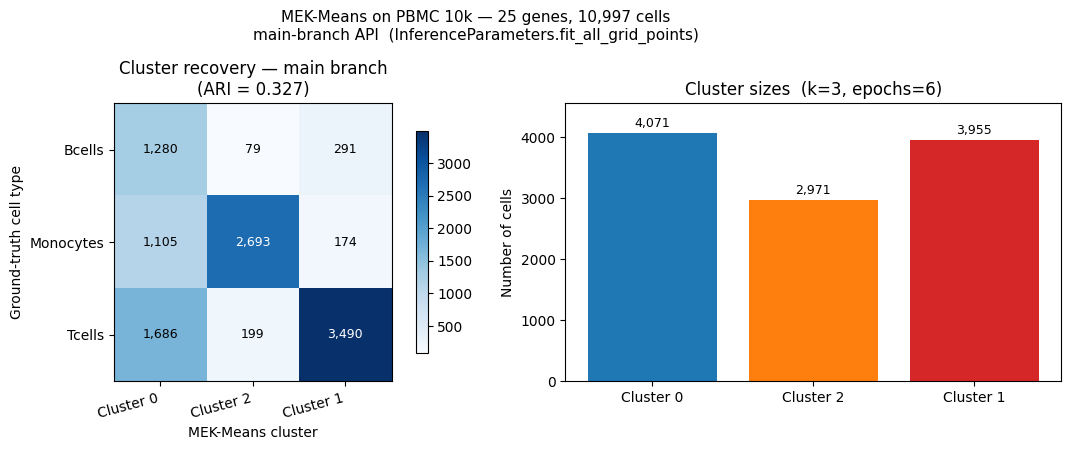

Saved figures/pbmc_mminference_main_confusion.png


In [7]:
# ── Confusion matrix figure ───────────────────────────────────────────────────
# Permute cluster labels so the dominant cell type per cluster runs top-left
# to bottom-right (purely cosmetic; does not affect ARI).
row_ind, col_ind = linear_sum_assignment(-cm)
cm_aligned = cm[:, col_ind]
cluster_labels_aligned = [f'Cluster {col_ind[j]}' for j in range(K)]
type_labels = sorted(unique_types)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Panel 1: confusion matrix ─────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(cm_aligned, cmap='Blues')
ax.set_xticks(range(K));           ax.set_xticklabels(cluster_labels_aligned, rotation=15, ha='right')
ax.set_yticks(range(len(type_labels))); ax.set_yticklabels(type_labels)
ax.set_xlabel('MEK-Means cluster'); ax.set_ylabel('Ground-truth cell type')
ax.set_title(f'Cluster recovery — main branch\n(ARI = {ari:.3f})')
thresh = cm_aligned.max() * 0.5
for i in range(len(type_labels)):
    for j in range(K):
        ax.text(j, i, f'{cm_aligned[i,j]:,}', ha='center', va='center',
                color='white' if cm_aligned[i,j] > thresh else 'black', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)

# ── Panel 2: cluster size bar chart ──────────────────────────────────────────
ax = axes[1]
bars = ax.bar(cluster_labels_aligned, counts_k[col_ind],
              color=plt.cm.tab10(np.linspace(0, 0.3, K)))
for b, c in zip(bars, counts_k[col_ind]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50,
            f'{c:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of cells')
ax.set_title(f'Cluster sizes  (k={K}, epochs={EPOCHS})')
ax.set_ylim(0, counts_k.max() * 1.12)

fig.suptitle(
    f'MEK-Means on PBMC 10k — {N_GENES} genes, {search_data.n_cells:,} cells\n'
    f'main-branch API  (InferenceParameters.fit_all_grid_points)',
    fontsize=11,
)
fig.tight_layout()
plt.savefig('figures/pbmc_mminference_main_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pbmc_mminference_main_confusion.png')